In [1]:
import torch

print("cuda available" if torch.cuda.is_available() else "cuda unavailable")
print("gpu ready" if torch.cuda.device_count() else "only cpu")

cuda available
gpu ready


In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [3]:
data_path = Path("..") / "data/metadata/engineered/training_pop40_genres.parquet"
_df = pd.read_parquet(data_path)
print(f"Loaded {len(_df):,} tracks from {data_path}")

Loaded 561,314 tracks from ../data/engineered/training_pop40_genres.parquet


# Data prep

In [4]:
from ast import literal_eval


df = _df.astype({
    "album_type": "category",
    "_label_size": "float32",
})

if pd.api.types.is_string_dtype(df["_artist_genres"]):
    df["_artist_genres"] = df["_artist_genres"].map(literal_eval)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561314 entries, 0 to 561313
Data columns (total 28 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   track_rowid              561314 non-null  int64   
 1   track_name               561314 non-null  string  
 2   artist_name              561314 non-null  string  
 3   artist_rowid             561314 non-null  int64   
 4   album_rowid              561314 non-null  int64   
 5   album_name               561314 non-null  string  
 6   artist_genres            561314 non-null  string  
 7   _artist_genres           561314 non-null  object  
 8   album_type               561314 non-null  category
 9   _label_size              561314 non-null  float32 
 10  _time_signature_is_four  561314 non-null  bool    
 11  _key_cos                 561314 non-null  float32 
 12  _key_sin                 561314 non-null  float32 
 13  mode                     561314 non-null  bo

## Train-valid split

We split selecting artists at random to minimize data leakage from duplicate tracks.

In [6]:
np.random.seed(0)

artists_unique = df["artist_rowid"].unique()
nartists_train = int(0.8 * len(artists_unique))
artists_train = np.random.choice(artists_unique, replace=False, size=nartists_train)

_shuffled = df.sample(frac=1, replace=False, ignore_index=True, random_state=0)
train_mask = _shuffled["artist_rowid"].isin(artists_train)
dft = _shuffled[train_mask].reset_index(drop=True)
dfv = _shuffled[~train_mask].reset_index(drop=True)

print(f"train amounts to {100 * len(dft) / len(df):.1f} % of the dataset")

train amounts to 80.2 % of the dataset


## Indexing genres

In [7]:
from collections import defaultdict
from ast import literal_eval
from autoencoder.preprocessing import CLEAN_UNKNOWN_GENRE_DEFAULT


def build_genre_vocab(genres: pd.Series) -> defaultdict[str, int]:
    UNKNOWN_INDEX = 0
    vocab = defaultdict(lambda: UNKNOWN_INDEX)
    vocab[CLEAN_UNKNOWN_GENRE_DEFAULT] = UNKNOWN_INDEX
    for gs in genres:
        for g in gs:
            if g not in vocab:
                vocab[g] = len(vocab)
    return vocab

genre2idx = build_genre_vocab(dft["_artist_genres"])
print(f"Found {len(genre2idx)} genres.")

Found 647 genres.


In [8]:
from collections import Counter

def genre_count(s: pd.Series) -> Counter:
    counter = Counter()
    for gs in s:
        for g in gs:
            counter[g] +=1
    return counter
    
def genre_idx_count(s: pd.Series, genre2idx: dict) -> torch.Tensor:
    counter = genre_count(s)
    cs = [-1] * len(genre2idx)
    for g, i in genre2idx.items():
        cs[i] = counter[g]
    assert -1 not in cs
    return torch.Tensor(cs)

# the plus 1 is added because we are going to use these as weights 
# and it could in principle happen that the unknown genre fallback counts zero.
genre_idx_counts = genre_idx_count(dft["_artist_genres"], genre2idx) + 1.

## Standardization

In [9]:
from sklearn.preprocessing import RobustScaler, MinMaxScaler


ZSCORE_COLS = ["tempo", "duration_ms", "danceability", "energy", "_loudness", "liveness", "valence"]
MINMAX_COLS = ["_release_year", "speechiness", "acousticness", "instrumentalness", "_label_size"]

zscore_scaler = RobustScaler().fit(dft[ZSCORE_COLS])
minmax_scaler = MinMaxScaler(feature_range=(-1, 1)).fit(dft[MINMAX_COLS])

for split_df in [dft, dfv, df]:
    split_df[ZSCORE_COLS] = zscore_scaler.transform(split_df[ZSCORE_COLS])
    split_df[MINMAX_COLS] = minmax_scaler.transform(split_df[MINMAX_COLS])

### Visualizing

In [10]:
if (_plot_train_correlations := False):
    features = [
        "tempo", "duration_ms", "_release_year", "danceability", "energy",
        "_loudness", "speechiness", "acousticness", "instrumentalness",
        "liveness", "valence", "_label_size",
    ]
    n_feat = len(features)
    fig, axes = plt.subplots(n_feat, n_feat, figsize=(12,12))
    
    for i in range(n_feat):
        for j in range(n_feat):
            ax = axes[i, j]
            if i == j:
                ax.hist(dft[features[i]], bins=30, color='steelblue', edgecolor='white')
            else:
                ax.hist2d(dft[features[j]], dft[features[i]], bins=30)
            
            if i == n_feat - 1:
                ax.set_xlabel(features[j], rotation=45, ha='right')
                ax.tick_params(axis='x', labelsize=7, rotation=45)
            else:
                ax.set_xticks([])
                
            if j == 0:
                ax.set_ylabel(features[i])
                ax.tick_params(axis='y', labelsize=7)
            else:
                ax.set_yticks([])
    
    plt.tight_layout()
    plt.show()

# Dataset & DataLoader

In [11]:
import torch
from torch.utils.data import Dataset


class TrackDataset(Dataset):
    def __init__(self, df: pd.DataFrame, genre2idx: dict[str, int]):
        # genres multi-hot
        self.genres = torch.zeros(len(df), len(genre2idx), dtype=torch.float32)
        for i, gs in enumerate(df["_artist_genres"]):
            for g in gs:
                self.genres[i, genre2idx[g]] = 1.
        # float variables
        self.numeric = torch.tensor(
            df[[
                "_label_size",
                "_release_year",
                "_release_yday_cos",
                "_release_yday_sin",
                "_key_cos", 
                "_key_sin",
                "mode",
                "tempo",
                "_time_signature_is_four",
                "danceability",
                "energy",
                "_loudness",
                "speechiness",
                "acousticness",
                "instrumentalness",
                "liveness",
                "valence",
                "explicit",
                "duration_ms",
            ]].values.astype(float), 
            dtype=torch.float32
        )
        self._len = len(df)

    def __len__(self):
        return self._len

    def __getitem__(self, idx):
        return (
            self.genres[idx],
            self.numeric[idx],
        )

def collate_fn(batch):
    genres, numeric = zip(*batch)
    return {
        "genres": torch.stack(genres),
        "numeric": torch.stack(numeric),
    }

In [12]:
from torch.utils.data import DataLoader
from torch import optim


print("Creating dataloaders..")
train_dataset = TrackDataset(dft, genre2idx=genre2idx)
valid_dataset = TrackDataset(dfv, genre2idx=genre2idx)
train = DataLoader(train_dataset, batch_size=1024, shuffle=True, num_workers=20, pin_memory=True, collate_fn=collate_fn)
valid = DataLoader(valid_dataset, batch_size=1024, num_workers=20, pin_memory=True, collate_fn=collate_fn)

Creating dataloaders..


# Model

In [13]:
import torch.nn as nn



class Encoder(nn.Module):
    def __init__(
        self, 
        ngenres: int,
        nnumeric: int,
        genre_embedding_dim: int,
        latent_dim: int,
        hidden_dim: list[int], 
        leaky_relu: float = 0.1,
        dropout: float = 0.1,
    ):
        if not hidden_dim:
            raise ValueError("Requires at least 1 hidden layer.")
            
        super().__init__()
        self.genre_embedding = nn.Sequential(
            nn.Linear(ngenres, genre_embedding_dim),
            nn.LeakyReLU(leaky_relu),
            nn.Dropout(dropout),
        )
        dim_in = genre_embedding_dim + nnumeric
        self.input = nn.Sequential(
            nn.Linear(dim_in, hidden_dim[0]),
            nn.LeakyReLU(leaky_relu),
        )
        layers = [
            layer
            for hdin, hdout in zip(hidden_dim[:-1], hidden_dim[1:])
            for layer in (
                nn.Linear(hdin, hdout),
                nn.LeakyReLU(leaky_relu),
                nn.Dropout(dropout)
            )
        ]
        self.hidden = nn.Sequential(*layers[:-1])  # remove last dropout
        self.mean = nn.Linear(hidden_dim[-1], latent_dim)
        self.logvar = nn.Linear(hidden_dim[-1], latent_dim)

    def embed(self, batch: dict) -> torch.Tensor:
        return torch.cat((
            self.genre_embedding(batch["genres"]),
            batch["numeric"],
        ), dim=1)
        
    def forward(self, batch: dict) -> tuple[torch.Tensor, torch.Tensor]:
        z = self.hidden(self.input(self.embed(batch)))
        return self.mean(z), self.logvar(z)


class Decoder(nn.Module):
    def __init__(
        self, 
        ngenres: int, 
        nnumeric: int, 
        latent_dim: int,
        hidden_dim: list[int], 
        leaky_relu: float = 0.1,
    ):
        if not hidden_dim:
            raise ValueError("Requires at least 1 hidden layer.")
        super().__init__()
        self.input = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim[0]),
            nn.LeakyReLU(leaky_relu),
        )
        layers = [
            layer
            for hdin, hdout in zip(hidden_dim[:-1], hidden_dim[1:])
            for layer in (
                nn.Linear(hdin, hdout),
                nn.LeakyReLU(leaky_relu),
            )
        ]
        self.hidden = nn.Sequential(*layers)
        self.head_genres = nn.Linear(hidden_dim[-1], ngenres)
        self.head_numeric = nn.Linear(hidden_dim[-1], nnumeric)

    def forward(self, batch: torch.Tensor):
        zs = self.hidden(self.input(batch))
        return {
            "genres": self.head_genres(zs),
            "numeric": self.head_numeric(zs),  
        }


def reparametrization(mean: torch.Tensor, std: torch.Tensor) -> torch.Tensor:
    epsilon = torch.randn_like(std)
    z = mean + std * epsilon
    return z

    
class TrackVAE(nn.Module):
    def __init__(
        self, 
        ngenres: int, 
        nnumeric: int, 
        latent_dim: int,
        hidden_dim: list[int], 
        genre_embedding_dim: int,
        leaky_relu: float = 0.1,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.encoder = Encoder(
            ngenres=ngenres,
            nnumeric=nnumeric,
            genre_embedding_dim=genre_embedding_dim,
            latent_dim=latent_dim,
            hidden_dim=hidden_dim, 
            leaky_relu=leaky_relu,
            dropout=dropout,
        )
        self.decoder = Decoder(
            ngenres=ngenres, 
            nnumeric=nnumeric, 
            latent_dim=latent_dim,
            hidden_dim=hidden_dim[::-1],
            leaky_relu=leaky_relu,
        )

    def forward(self, x: dict):
        mean, logvar = self.encoder(x)
        z = reparametrization(mean, torch.exp(0.5 * logvar))
        y: dict = self.decoder(z)
        return y, mean, logvar

# Loss

In [14]:
from typing import Callable


def get_metrics(
    beta: float=1., 
    weights=None, 
    genre_weights=None) -> Callable:
    bce = nn.BCEWithLogitsLoss(pos_weight=genre_weights)
    mse = nn.MSELoss()
    
    wkeys = ["genres", "numeric"]
    if weights is None:
        weights = {}
    elif any([k not in wkeys for k in weights]):
        raise ValueError(f"Wrong key for weights. Allowed keys are: {', '.join(wkeys)}")
    weights |= {k: 1.0 for k in wkeys if k not in weights}

    def compute_batch_metrics(predictions, targets) -> dict:
        ys, mean, logvar = predictions
        KLD = - beta * (0.5 * torch.mean(1 + logvar - mean.pow(2) - logvar.exp()))
        
        # head losses
        l_genres = bce(ys["genres"], targets["genres"])
        l_numeric = mse(ys["numeric"], targets["numeric"])
        total = (
            l_numeric * weights["numeric"] +
            l_genres * weights["genres"]
        ) / sum(weights.values()) + KLD

        # multilabel classifier metrics
        genres_probs = torch.sigmoid(ys["genres"].detach())
        genres_bpreds = (genres_probs > 0.5).float()
        _tp = (genres_bpreds * targets["genres"]).sum()
        _fp = (genres_bpreds * (1. - targets["genres"])).sum()
        _fn = ((1 - genres_bpreds) * targets["genres"]).sum()
        genres_prc = (_tp) / (_tp + _fp + (eps:=1.e-6))
        genres_rec = (_tp) / (_tp + _fn + eps)
        genres_f1 = 2 * genres_prc * genres_rec / (genres_prc + genres_rec + eps)
        return {
            "total": total,
            "kld": KLD.item(),
            "genres": l_genres.item(),
            "numeric": l_numeric.item(),
            "genres_prc": genres_prc.item(),
            "genres_rec": genres_rec.item(),
            "genres_f1": genres_f1.item(),
        }
    
    return compute_batch_metrics

# Training

In [16]:
MODEL_PARAMETERS = {
    "latent_dim": 128,
    "hidden_dim": [1024, 512, 256],
    "genre_embedding_dim": 256,
    "leaky_relu": 0.1,
    "dropout": 0.1,
}
LOSS_PARAMETERS ={ 
    "weights": {
        "numeric": 5., 
        "genres": 1.,
    },
    "beta": .1,
}
SCHEDULER_PARAMETERS = {
    "factor": 0.5, 
    "patience": 5,
}
NEPOCHS, LR = 60, 1e-3

In [17]:
import time
from torch.optim.lr_scheduler import ReduceLROnPlateau

torch.set_float32_matmul_precision('high')


def log_epoch(epoch, t, train_metrics, valid_metrics, best_epoch=None, scheduler=None):
    lr_str = f", LR: {scheduler.get_last_lr()[0]:.1e}" if scheduler else ""
    print(f"\n{'='*5} EPOCH {epoch:02d} (Time: {t:.2f}s{lr_str}) {'='*5}")
    
    header = f"{'Metric':<15} | {'Train':<10} | {'Valid':<10}"
    print(header)
    print("-" * len(header))
    
    for key in train_metrics.keys():
        t_val = train_metrics[key]
        v_val = valid_metrics[key]
        print(f"{key.replace('_', ' ').title():<15} | {t_val:<10.5f} | {v_val:<10.5f}")

    if best_epoch == epoch:
        print("* Best epoch so far!")
        

print("Initializing model..")
model = TrackVAE(
    ngenres=len(genre2idx),
    nnumeric=train_dataset.numeric.shape[1],
    **MODEL_PARAMETERS
)
device = torch.device("cuda")
model = model.to(device)
model.compile()
print(model, end="\n\n")

history = []
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, "min", **SCHEDULER_PARAMETERS)
compute_metrics = get_metrics(
    genre_weights= (genre_idx_counts.sum() / genre_idx_counts).sqrt().to(device),
    **LOSS_PARAMETERS,
)
best_valid_loss = float("inf")
best_state, best_epoch = None, -1
t0 = time.time()
print(f"Training on {len(train_dataset)} rows..")
for epoch in range(NEPOCHS):
    model.train()
    train_metrics = {}
    
    for batch in train:
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()

        xs = model(batch)
        batch_metrics = compute_metrics(xs, batch)
        batch_metrics["total"].backward()
        optimizer.step()
        
        for k in batch_metrics.keys():
            val = batch_metrics[k]
            train_metrics.setdefault(k, 0.)
            train_metrics[k] += val.item() if isinstance(val, torch.Tensor) else val
            
    model.eval()
    valid_metrics = {}
    with torch.no_grad():
        for batch in valid:
            batch = {k: v.to(device) for k, v in batch.items()}
            xs = model(batch)
            batch_metrics = compute_metrics(xs, batch)
            
            for k in batch_metrics.keys():
                val = batch_metrics[k]
                valid_metrics.setdefault(k, 0.)
                valid_metrics[k] += val.item() if isinstance(val, torch.Tensor) else val
    
    avg_train = {k: v / len(train) for k, v in train_metrics.items()}
    avg_valid = {k: v / len(valid) for k, v in valid_metrics.items()}
    scheduler.step(avg_valid["total"])
    if avg_valid["total"] < best_valid_loss:
        best_valid_loss = avg_valid["total"]
        best_epoch = epoch
        best_state = model.state_dict()
    if epoch % (PRINT_EVERY := 1) == 0: 
        log_epoch(epoch, time.time() - t0, avg_train, avg_valid, best_epoch, scheduler)
        history.append((avg_train, avg_valid))
    if scheduler.get_last_lr()[0] <= 2e-6:
        print("Minimum LR reached. Breaking.")
        break
        
model.load_state_dict(best_state)
print(f"Restored best model (valid loss: {best_valid_loss:.5f}, epoch: {best_epoch})")

Initializing model..
TrackVAE(
  (encoder): Encoder(
    (genre_embedding): Sequential(
      (0): Linear(in_features=647, out_features=256, bias=True)
      (1): LeakyReLU(negative_slope=0.1)
      (2): Dropout(p=0.1, inplace=False)
    )
    (input): Sequential(
      (0): Linear(in_features=275, out_features=1024, bias=True)
      (1): LeakyReLU(negative_slope=0.1)
    )
    (hidden): Sequential(
      (0): Linear(in_features=1024, out_features=512, bias=True)
      (1): LeakyReLU(negative_slope=0.1)
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=512, out_features=256, bias=True)
      (4): LeakyReLU(negative_slope=0.1)
    )
    (mean): Linear(in_features=256, out_features=128, bias=True)
    (logvar): Linear(in_features=256, out_features=128, bias=True)
  )
  (decoder): Decoder(
    (input): Sequential(
      (0): Linear(in_features=128, out_features=256, bias=True)
      (1): LeakyReLU(negative_slope=0.1)
    )
    (hidden): Sequential(
      (0): Linear(i

# Profiling

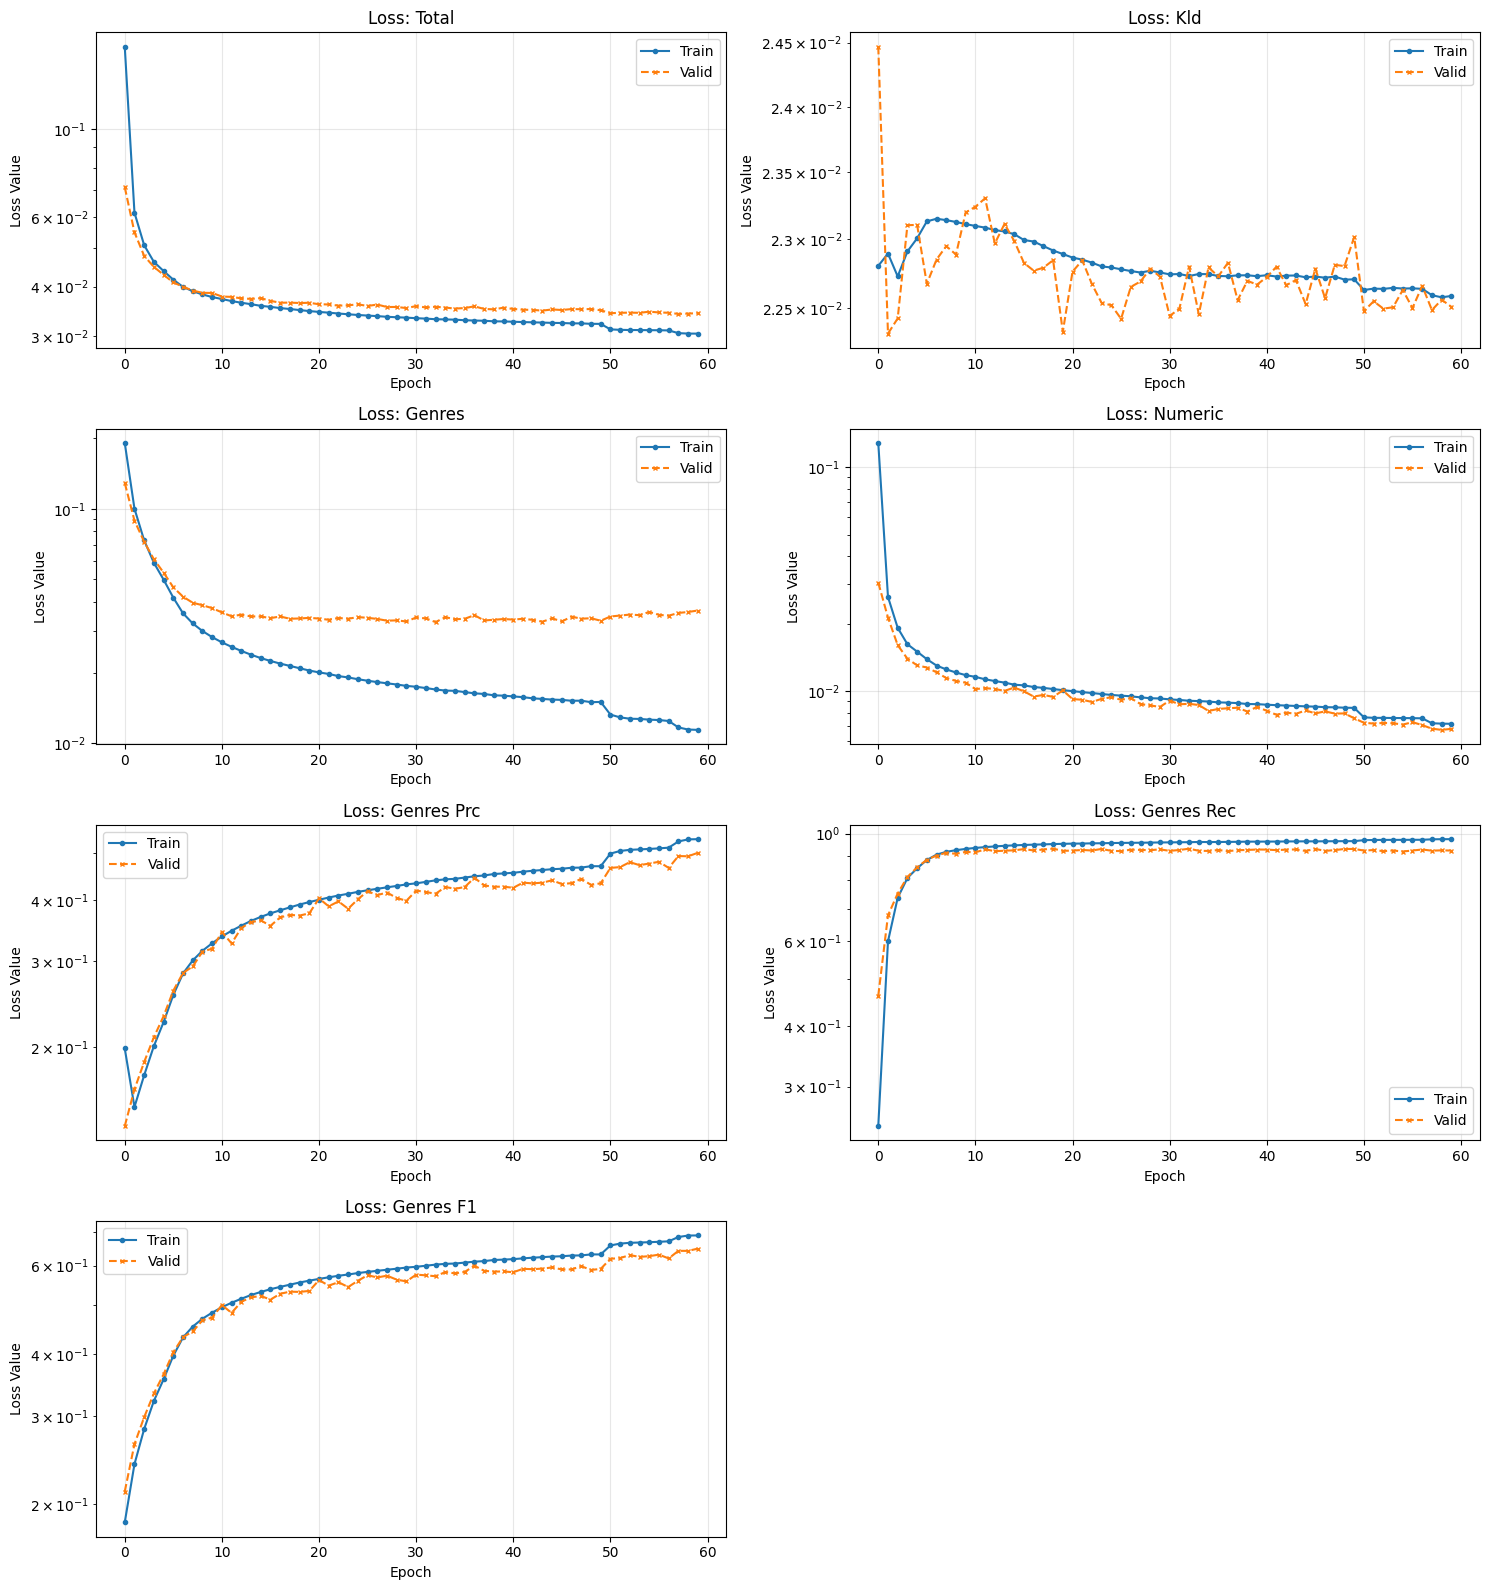

In [18]:
import matplotlib.pyplot as plt


def plot_training_results(history):
    metrics = list(history[0][0].keys())
    num_metrics = len(metrics)
    
    cols = 2
    rows = (num_metrics + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        train_vals = [h[0][metric] for h in history]
        valid_vals = [h[1][metric] for h in history]
        
        ax = axes[i]
        ax.plot(train_vals, label="Train", marker="o", markersize=3)
        ax.plot(valid_vals, label="Valid", linestyle="--", marker="x", markersize=3)
        
        title = metric.replace("_", " ").title()
        ax.set_title(f"Loss: {title}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss Value")
        ax.semilogy()
        ax.legend()
        ax.grid(True, alpha=0.3)
        if train_vals[0] / (train_vals[-1] + 1e-9) > 100:
            ax.set_yscale("log")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Use it like this:
plot_training_results(history)

In [19]:
import torch.nn.functional as F


def get_recommender(
    model: nn.Module, 
    device: torch.device, 
    df: pd.DataFrame, 
    genre2idx: dict, 
):
    @torch.no_grad()
    def get_all_embeddings():
        dataset = TrackDataset(df, genre2idx=genre2idx)
        dl = DataLoader(dataset, batch_size=1024, shuffle=False, num_workers=20, collate_fn=collate_fn)
        means, stds = [], []
        model.eval()
        for batch in dl:
            batch = {k: v.to(device) for k, v in batch.items()}
            mean, logvar = model.encoder(batch)
            means.append(mean)
            stds.append(torch.exp(0.5 * logvar))
        return torch.cat(means, dim=0), torch.cat(stds, dim=0)

    def recommend(artist: str, track: str, n: int=10, temperature: float=0.):
        match = df[(df["artist_name"] == artist) & (df["track_name"] == track)]
        if match.empty: 
            return "Track not found."
        idx = match.index[0]
        query_vec = Z_mean[idx]
        query_vec += temperature * Z_std[idx] * torch.randn_like(query_vec)
        sim = F.cosine_similarity(query_vec, Z_mean)
        scores, top_indices = torch.topk(sim, k=n+1)
        similiar_df = df.iloc[top_indices[1:].cpu()]
        return pd.DataFrame({
            "artist_name": similiar_df["artist_name"],
            "track_name": similiar_df["track_name"],
            "score": scores.cpu()[1:],
        })
        
    Z_mean, Z_std = get_all_embeddings()        
    return recommend


recommend = get_recommender(model, device, df, genre2idx)

In [20]:
recommend("Joy Division", "Disorder", 10, temperature=0)

,artist_name,track_name,score
436216,Howard Jones,What Is Love?,0.905337
442169,The Cure,Play For Today,0.897487
230367,Casket Cassette,Bouquet,0.893107
187926,Public Memory,Heir,0.889457
235522,The Cure,Cold,0.886626
210177,Placebo,English Summer Rain,0.873714
190624,Placebo,Daddy Cool,0.869249
227333,Crossfade,The Unknown,0.869061
536670,Moby,Extreme Ways,0.868174
19598,TR/ST,Shoom,0.864016


In [21]:
recommend("MF DOOM", "Doomsday", 10, temperature=0)

,artist_name,track_name,score
247547,Souls Of Mischief,Live and Let Live,0.914050
465905,Cypress Hill,Siempre Peligroso (feat. Fermin IV Caballero),0.904796
378,Black Star,Hater Players,0.895736
554588,N.W.A.,Fuck Tha Police,0.893613
402407,People Under The Stairs,San Francisco Knights,0.888175
406498,Ice Cube,Do Ya Thang,0.881636
560857,Outkast,Ms. Jackson,0.877175
60915,The Pharcyde,4 Better Or 4 Worse,0.874036
212273,Xzibit,Multiply (feat. Nate Dogg),0.871101
343602,MF DOOM,The Finest,0.870041


In [22]:
recommend("CCCP – Fedeli Alla Linea", "Io Sto Bene", 10, temperature=0)

,artist_name,track_name,score
308084,Tiziano Ferro,Incanto,0.925989
84426,Simon Webbe,Coming Around Again,0.901981
164350,ItaloBrothers,Moonlight Shadow,0.896196
308103,Michael Learns To Rock,It's Gonna Make Sense,0.874474
196346,kaneto-juusei,rusubandenwa,0.872893
178960,Kasia Kowalska,To co dobre,0.871947
330895,G2,Detonate,0.858722
94332,Nicolas Peyrac,Le vin me saoule,0.858275
554632,Lenny Kravitz,Again,0.857180
529049,Matt and Kim,Daylight,0.856393
